In [48]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib.gridspec import GridSpec

os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV')
sns.set_style('white')

# To do (copy and edit further on next notebook)
* Precision/recall curves as a function of SV size: germline and simulation
    * x-axis points have to be analyzed as separate runs of truvari: immediate task is to plot existing SV distributions of both germline and simulation.
        * Completed below, new TODO: set bins for bcftools filter to <= 100, <= 250, <= 500, <= 750, <= 1000, <= 2500, <= 5000, <= 7500, <= 10000.

**Just realized after looking at size plots: I should have filtered the benchmark set to SVs <10 kb.** I was filtering my callset to <10kb, and I did the subsetting of the benchmark to ins/del because I realized it was affecting recall... I didn't make the connection about not subsetting the benchmark set by size affecting recall. It's probably better to keep appropriate benchmark subsets inside the simulation subset folder so everything is appropriately matched. I corrected and adjusted that in the last `hg38_benchmark.ipynb` notebook.

* Convert truvari false negative of simulations to bedfile
    * Identify if any reads from HG002_subsampled bamfile overlap the false negative bedfile: describes more accurately actual false negatives, because the variants without ANY reads on top should never be included as part of the comparison set (improves recall). 
        * Can use `bedtools coverage`
* Improve precision by restricting SV candidates from simulation to those with high confidence flanking sequences around SV breakpoints
    * Maybe this exists somewhere already? If not, go from `sniffles` output: 1) pull ALT sequence (for INS), 2) `RNAMES` -> pull sequence from bamfile, 3) for ins, substring search with str methods: make sure index location is some % flanked on each side on the bread, 4) for del, more complex... check mapping position of start/end of read, compare to breakpoint proposed by sniffles, make sure breakpoint location vs. read map location is some % flanked
* Pop open the false positive file, break down...
    * Chromosome position
    * SV length
    * For insertions: insertion content
* Check if false positives (1 read support) are present in germline calls and contribute to a true call.

Lower tier ideas:
* Use H1/H2 assemblies from `hifiasm` on each sample: generate simulated reads, use as "normal" sample + actual sample as "tumor" sample on matched tumor-normal callers like deepSomatic (and other ones???)
    * Can also test this idea with hg38 + in silico SV reads
* Use H1/H2 assemblies from `hifiasm` and remap reads to their own matched assemblies, rerun pipeline
    * This one is not the lowest tier, we already have these assemblies for each sample – can also test this idea with hg38 + in silico SV reads
* Look at what the hell Cue is doing for somatic SV calling. Is it only short read???

# SV size distributions

In [23]:
# use zcat {path.vcf.gz} | grep -n '#CHROM' to get position of end of header
germline_vcf = pd.read_table('output/mapping/hg38_old/sniffles/standard/single_sample/HG002.vcf.gz', skiprows=241)
germline_vcf['SVLEN'] = germline_vcf['INFO'].str.extract("(?<=SVLEN=)(.+)(?=;END)").astype(float)
germline_vcf['Callset'] = "germline"
germline_vcf['RNAMES'] = germline_vcf['INFO'].str.extract("(?<=RNAMES=)(.+)(?=;C)")
germline_vcf['RNAMES'] = germline_vcf['RNAMES'].str.replace("m84053_230601_202536_s4", "894")
germline_vcf['RNAMES'] = germline_vcf['RNAMES'].str.replace("m84053_230629_234400_s4", "894")
germline_vcf['RNAMES'] = germline_vcf['RNAMES'].str.replace("m84039_230117_233243_s1", "HG002")
germline_vcf['support_reads'] = germline_vcf['SAMPLE'].str.split(':', expand = True)[3].astype(int)
germline_vcf['Origin'] = 'HG002'

sim_vcf = pd.read_table('output/mapping/hg38_old/simulations/merge_mapped/raw/HG002_894_simulation.vcf.gz', skiprows=241)
sim_vcf['SVLEN'] = sim_vcf['INFO'].str.extract("(?<=SVLEN=)(.+)(?=;END)").astype(float)
sim_vcf['Callset'] = "simulation"
sim_vcf['RNAMES'] = sim_vcf['INFO'].str.extract("(?<=RNAMES=)(.+)(?=;C)")
sim_vcf['RNAMES'] = sim_vcf['RNAMES'].str.replace("m84053_230601_202536_s4", "894")
sim_vcf['RNAMES'] = sim_vcf['RNAMES'].str.replace("m84053_230629_234400_s4", "894")
sim_vcf['RNAMES'] = sim_vcf['RNAMES'].str.replace("m84039_230117_233243_s1", "HG002")
sim_vcf['support_reads'] = sim_vcf['SAMPLE'].str.split(':', expand = True)[3].astype(int)
sim_vcf['Origin'] = [x.split('/')[0] if len(x.split(',')) == 1 else 'NA' for x in sim_vcf['RNAMES']]

concat = pd.concat([germline_vcf, sim_vcf]).reset_index(drop = True)

## Raw distribution of variants in germline vs. simulation

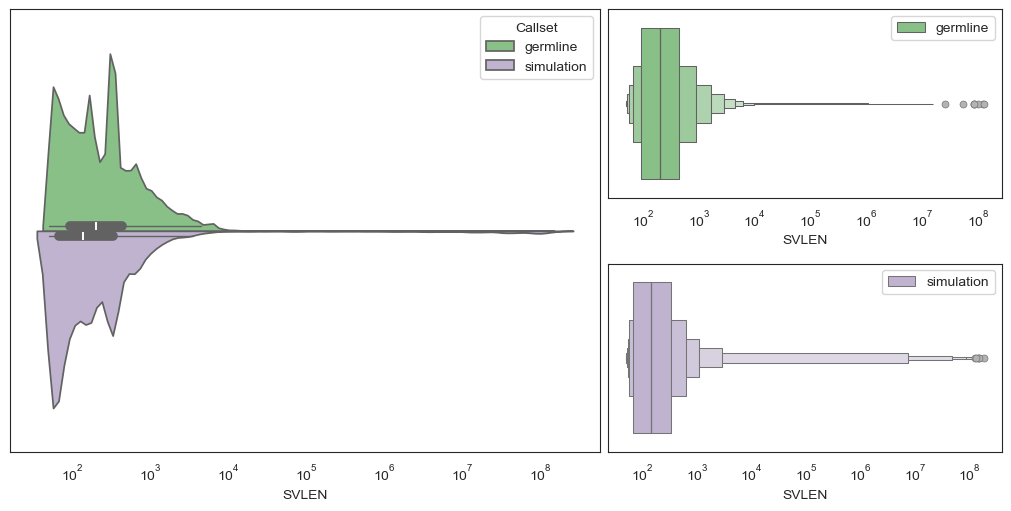

In [59]:
fig = plt.figure(figsize=(10,5), layout='constrained')

gs = GridSpec(2, 5, figure = fig)
ax1 = fig.add_subplot(gs[:,:3])
ax2 = fig.add_subplot(gs[0,3:5])
ax3 = fig.add_subplot(gs[1,3:5])

with sns.color_palette("Accent"):
    sns.violinplot(ax = ax1, data=concat, x = 'SVLEN', hue = 'Callset', split = 'True', log_scale = True, bw_adjust = 0.5, inner_kws=dict(box_width=7, whis_width=1))
    sns.boxenplot(ax = ax2, data=germline_vcf, x = 'SVLEN', hue = 'Callset', log_scale = True, flier_kws=dict(facecolor=".7", linewidth=.5))
    ax2.legend()
sns.boxenplot(ax = ax3, data=sim_vcf, x = 'SVLEN', hue = 'Callset', log_scale = True, palette = sns.color_palette("Accent")[1:2], flier_kws=dict(facecolor=".7", linewidth=.5))
ax3.legend()

## Distribution of variants in germline vs. simulation (HG002, 1 support read)

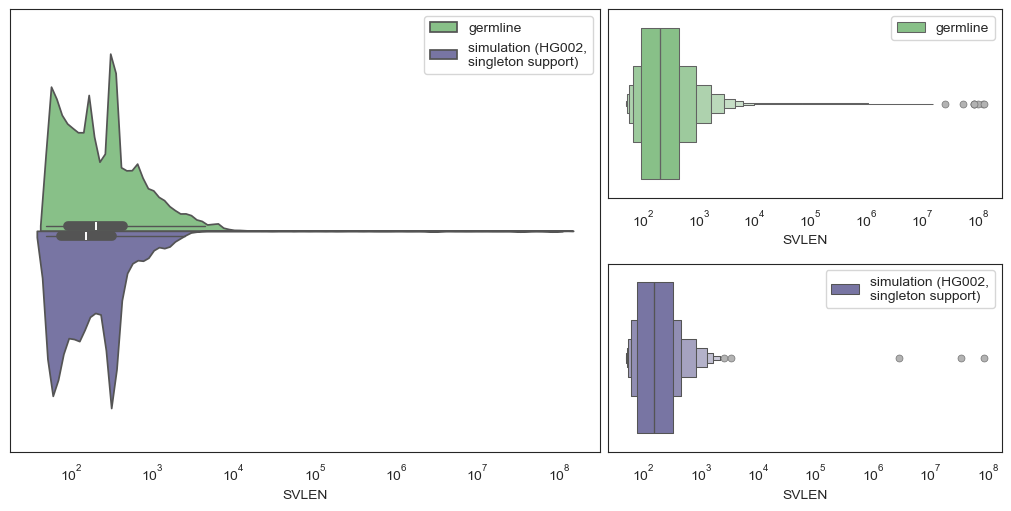

In [60]:
fig = plt.figure(figsize=(10,5), layout='constrained')

gs = GridSpec(2, 5, figure = fig)
ax1 = fig.add_subplot(gs[:,:3])
ax2 = fig.add_subplot(gs[0,3:5])
ax3 = fig.add_subplot(gs[1,3:5])

# use list(map(mpl.colors.rgb2hex, sns.color_palette("Accent")))
# to get hex codes for palettes & adjust in color picker

sns.violinplot(ax = ax1, data=pd.concat([germline_vcf, sim_vcf.query("support_reads == 1 & Origin == 'HG002'")]).reset_index(drop = True),
    x = 'SVLEN', hue = 'Callset', split = 'True', log_scale = True, bw_adjust = 0.5, inner_kws=dict(box_width=7, whis_width=1),
    palette = ['#7fc97f', '#726dab'])
ax1.legend(handles = ax1.get_legend_handles_labels()[0], labels=['germline', 'simulation (HG002,\nsingleton support)'])
sns.boxenplot(ax = ax2, data=concat.query("Callset == 'germline'"), x = 'SVLEN', hue = 'Callset', log_scale = True, 
    flier_kws=dict(facecolor=".7", linewidth=.5), palette = ['#7fc97f'])
ax2.legend()
sns.boxenplot(ax = ax3, data=sim_vcf.query("support_reads == 1 & Origin == 'HG002'"), x = 'SVLEN', hue = 'Callset', log_scale = True, 
    palette = ['#726dab'], flier_kws=dict(facecolor=".7", linewidth=.5))
ax3.legend(handles = ax3.get_legend_handles_labels()[0], labels=['simulation (HG002,\nsingleton support)'])

## Distribution of <10 kb variants in germline vs. simulation (HG002, 1 support read)

/var/folders/d1/_d4s2fqs7_z4dhbkbh6b02xw0000gn/T/ipykernel_12137/4196158553.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 10000)


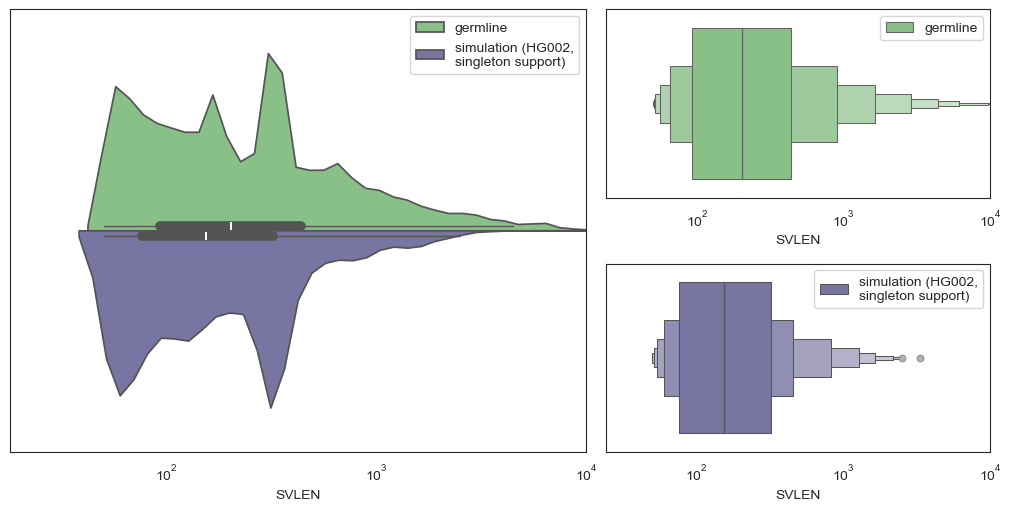

In [56]:
fig = plt.figure(figsize=(10,5), layout='constrained')

gs = GridSpec(2, 5, figure = fig)
ax1 = fig.add_subplot(gs[:,:3])
ax2 = fig.add_subplot(gs[0,3:5])
ax3 = fig.add_subplot(gs[1,3:5])

# use list(map(mpl.colors.rgb2hex, sns.color_palette("Accent")))
# to get hex codes for palettes & adjust in color picker

sns.violinplot(ax = ax1, data=pd.concat([germline_vcf, sim_vcf.query("support_reads == 1 & Origin == 'HG002'")]).reset_index(drop = True),
    x = 'SVLEN', hue = 'Callset', split = 'True', log_scale = True, bw_adjust = 0.5, inner_kws=dict(box_width=7, whis_width=1),
    palette = ['#7fc97f', '#726dab'])
ax1.legend(handles = ax1.get_legend_handles_labels()[0], labels=['germline', 'simulation (HG002,\nsingleton support)'])
sns.boxenplot(ax = ax2, data=concat.query("Callset == 'germline'"), x = 'SVLEN', hue = 'Callset', log_scale = True, 
    flier_kws=dict(facecolor=".7", linewidth=.5), palette = ['#7fc97f'])
ax2.legend()
sns.boxenplot(ax = ax3, data=sim_vcf.query("support_reads == 1 & Origin == 'HG002'"), x = 'SVLEN', hue = 'Callset', log_scale = True, 
    palette = ['#726dab'], flier_kws=dict(facecolor=".7", linewidth=.5))
ax3.legend(handles = ax3.get_legend_handles_labels()[0], labels=['simulation (HG002,\nsingleton support)'])

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0, 10000)